In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv


ModuleNotFoundError: No module named 'kagglehub'

**Avaliação do dataset Iris com SVM no Kaggle**

In [2]:
#Importar bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score


In [3]:
#conectar ao arquivo
df = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')
print(df)

      Id  SepalLengthCm  ...  PetalWidthCm         Species
0      1            5.1  ...           0.2     Iris-setosa
1      2            4.9  ...           0.2     Iris-setosa
2      3            4.7  ...           0.2     Iris-setosa
3      4            4.6  ...           0.2     Iris-setosa
4      5            5.0  ...           0.2     Iris-setosa
..   ...            ...  ...           ...             ...
145  146            6.7  ...           2.3  Iris-virginica
146  147            6.3  ...           1.9  Iris-virginica
147  148            6.5  ...           2.0  Iris-virginica
148  149            6.2  ...           2.3  Iris-virginica
149  150            5.9  ...           1.8  Iris-virginica

[150 rows x 6 columns]


#X ira retirar a coluna especie e id( ira considerar apenas as demais colunas)
X= df.drop(id, Species)

#Y ira considerar apoenas a coluna Species
y= df.Species

In [4]:
#X ira retirar a coluna especie e id( ira considerar apenas as demais colunas)
X= df.drop(columns=['Id', 'Species'])

#Y ira considerar apenas a coluna Species
y= df['Species']

print(X)

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              5.1           3.5            1.4           0.2
1              4.9           3.0            1.4           0.2
2              4.7           3.2            1.3           0.2
3              4.6           3.1            1.5           0.2
4              5.0           3.6            1.4           0.2
..             ...           ...            ...           ...
145            6.7           3.0            5.2           2.3
146            6.3           2.5            5.0           1.9
147            6.5           3.0            5.2           2.0
148            6.2           3.4            5.4           2.3
149            5.9           3.0            5.1           1.8

[150 rows x 4 columns]


In [5]:
#divide o conjunto de dados em treino e teste ( train and test) ( 80% treino e 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state = 42, stratify = y)

In [6]:
#Crie o modelo SVM (usando o kermel linear)
model = SVC (kernel = 'linear')

In [7]:
#treine o modelo com os dados de treino
model.fit(X_train, y_train)

In [8]:
#faça as previsões nos dados teste
y_pred = model.predict(X_test)

In [9]:
#Calcule a acuracia
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy * 100:.2f}%")

Acurácia do modelo: 100.00%


In [10]:
#exibe as previçoes de teste e valores reais

print("valores predito:", y_pred)
print("valores reais:", y_test)

valores predito: ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']
valores reais: 38         Iris-setosa
127     Iris-virginica
57     Iris-versicolor
93     Iris-versicolor
42         Iris-setosa
56     Iris-versicolor
22         Iris-setosa
20         Iris-setosa
147     Iris-virginica
84     Iris-versicolor
107     Iris-virginica
141     Iris-virginica
104     Iris-virginica
51     Iris-versicolor
7          Iris-setosa
49         Iris-setosa
14         Iris-setosa
69     Iris-versicolor
63     Iris-versicolor
138     Iris-virginica
10       

## Visualizações da análise

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")


### Gráfico 1 - Matriz de confusão do modelo SVM

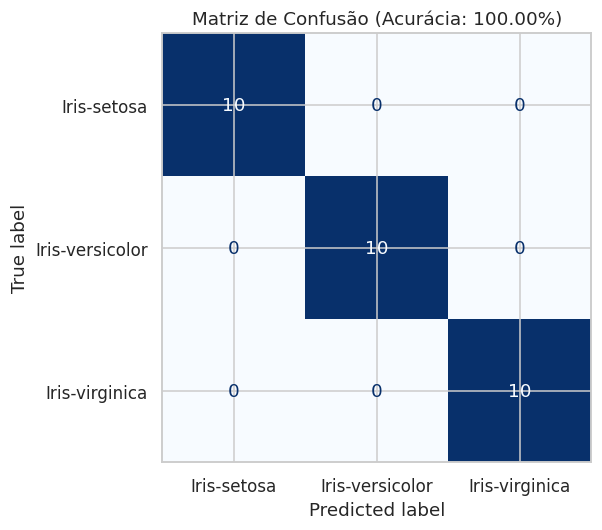

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(5.5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusão (Acurácia: {accuracy*100:.2f}%)')
plt.tight_layout()
plt.show()


### Gráfico 2 - Fronteira de decisão do SVM (Petal Length x Petal Width)

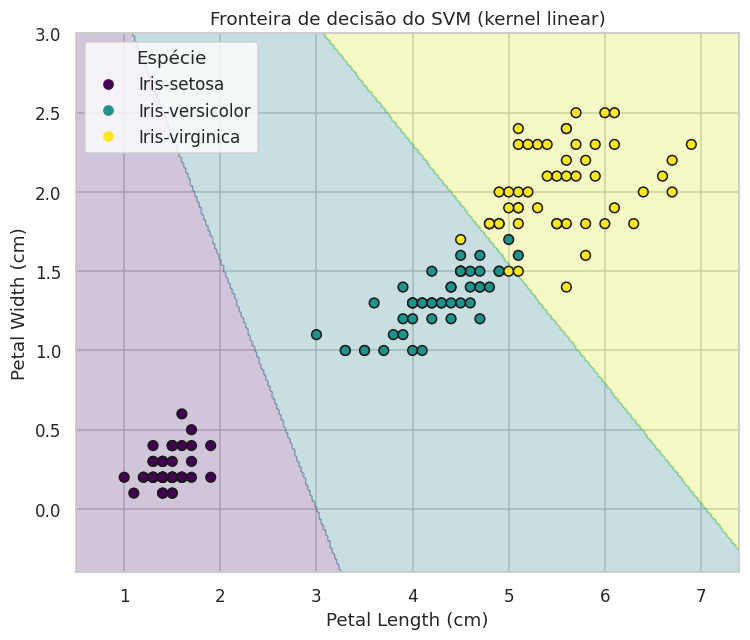

In [15]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
X2 = df[['PetalLengthCm','PetalWidthCm']].values
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
model2 = SVC(kernel='linear')
model2.fit(X2_train, y2_train)

x_min, x_max = X2[:,0].min()-0.5, X2[:,0].max()+0.5
y_min, y_max = X2[:,1].min()-0.5, X2[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = model2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7,6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap='viridis')
scatter = ax.scatter(X2[:,0], X2[:,1], c=y_enc, cmap='viridis', edgecolor='k', s=40)
handles, _ = scatter.legend_elements()
ax.legend(handles, le.classes_, title='Espécie')
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_title('Fronteira de decisão do SVM (kernel linear)')
plt.tight_layout()
plt.show()
